In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.spatial import distance
from scipy.stats import gaussian_kde
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from mpl_toolkits.mplot3d import Axes3D




%matplotlib widget

In [2]:
def find_closest_point_with_index(target, data_points):
    distances = np.linalg.norm(data_points - target, axis=1)
    closest_index = np.argmin(distances)
    return closest_index, data_points[closest_index]

def cubic(t, a, b, c, d):
    return a * t**3 + b * t**2 + c * t + d
    
def slerp(p0, p1, t):
    # Compute the dot product and clamp its value between -1 and 1
    dot = np.dot(p0 / np.linalg.norm(p0), p1 / np.linalg.norm(p1))
    dot = np.clip(dot, -1.0, 1.0)
    
    # Calculate the angle omega
    omega = np.arccos(dot)
    so = np.sin(omega)
    
    # Handle the case where the angle omega is zero (no interpolation needed)
    if so == 0.0:
        return p0
    
    # Perform SLERP interpolation
    return np.sin((1.0 - t) * omega) / so * p0 + np.sin(t * omega) / so * p1


In [3]:
device = 'cuda'

out_path = "./out/"
out_path_params = out_path + "Driver_XYZ_params/"
params_file_name = 'Driver_XYZ_Params'
# top_path = "../traj/cyclicpeptide/N4IR/N4IR.prmtop"
# path = "../traj/cyclicpeptide/ExoR2/Cyclic_Peptide_MinimizedSorted.dcd"
pdb_name = "Driver_Cyclic_Peptide_Prediction"

par_id = 200

# Load the latent space representation
all_z = np.load(out_path + 'visual/' + 'Driver_Cyclic_Peptide_Predictionlatent.npy')

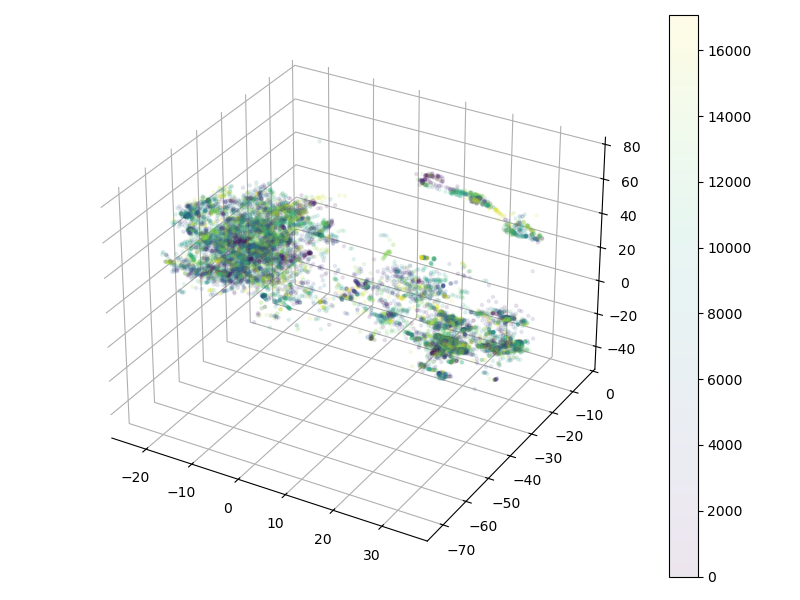

In [4]:
cmapT='viridis'
cmapV='winter'

fig = plt.figure(figsize = [8, 6])
ax = plt.axes(projection='3d')
p1 = ax.scatter3D(all_z[:,0], all_z[:,1], all_z[:,2], c=range(int(len(all_z))), alpha=0.1, cmap=cmapT, s=5)
# p2 = ax.scatter3D(interpolated_points[:,0], interpolated_points[:,1], interpolated_points[:,2], alpha=0.99, color='red')
# p3 = ax.scatter3D(interpolated_points1[:,0], interpolated_points1[:,1], interpolated_points1[:,2], alpha=0.99, color='blue')
# p3 = ax.scatter3D(centers[:,0], centers[:,1], centers[:,2], alpha=0.99, color='red')
# p3 = ax.scatter3D(expanded_points[:,0], expanded_points[:,1], expanded_points[:,2], alpha=0.99, color='red',s=1)



fig.colorbar(p1, ax=ax)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

# ax.set_xlabel('Z1'); ax.set_ylabel('Z2'); ax.set_zlabel('Z3')
fig.tight_layout()
#plt.savefig('3D_latent_9000-9100.png')
plt.show()

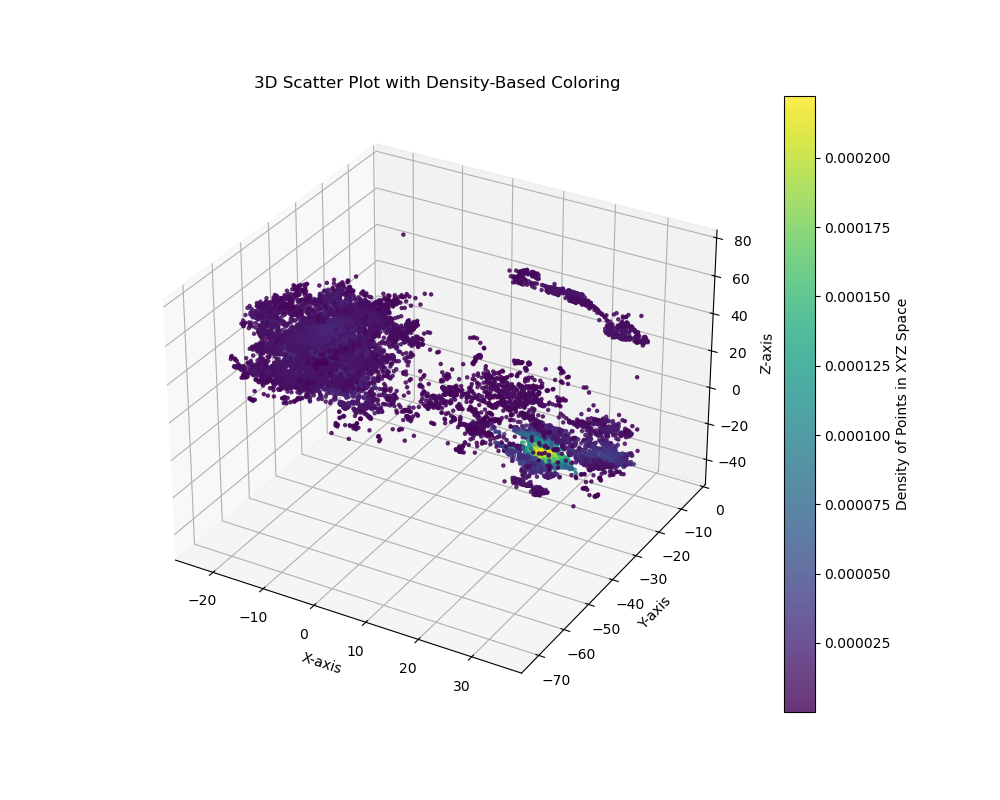

In [5]:
"""
Plot the density weighted scatter plot.
"""


x = all_z[:,0]
y = all_z[:,1]
z = all_z[:,2]

# Compute density using KDE
xyz = np.vstack([x, y, z])
density = gaussian_kde(xyz)(xyz)

# Sort data by density for smoother plotting
sorted_idx = np.argsort(density)
x, y, z, density = x[sorted_idx], y[sorted_idx], z[sorted_idx], density[sorted_idx]

# Create a grid for interpolation
grid_x, grid_y = np.linspace(-100, 100, 100), np.linspace(-100, 100, 100)
X, Y = np.meshgrid(grid_x, grid_y)

# Interpolate the z data onto the grid
Z = griddata((x, y), z, (X, Y), method='cubic')

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D scatter plot with density-based coloring
sc = ax.scatter3D(x, y, z, c=density, cmap='viridis', s=5, alpha=0.8)

# Add labels and title
ax.set_title('3D Scatter Plot with Density-Based Coloring')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')

# Add a color bar for density
cbar = fig.colorbar(sc, ax=ax, label='Density')
cbar.set_label('Density of Points in XYZ Space')

# Show the plot
plt.show()


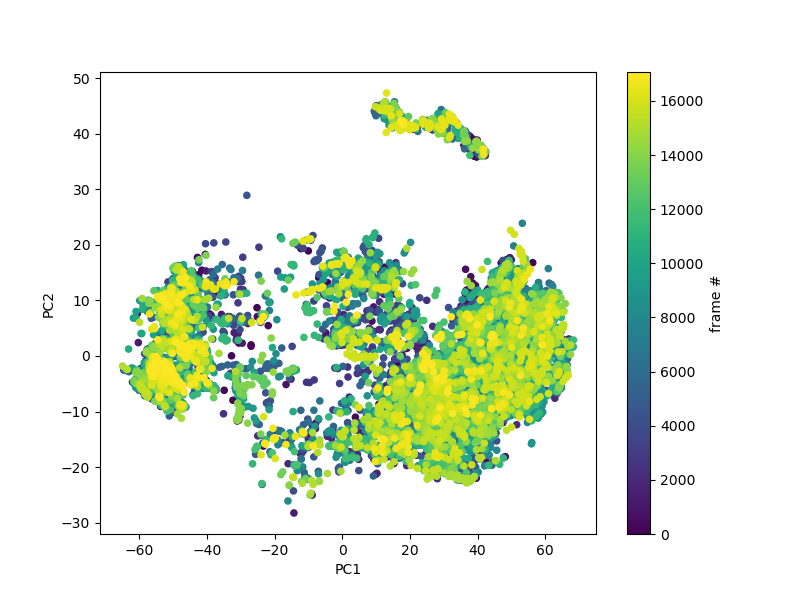

In [6]:
# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_z)
pc1, pc2 = pca_result[:, 0], pca_result[:, 1]


fig = plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:,1], marker='o', c=range(all_z.shape[0]), s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
cbar = plt.colorbar()
cbar.set_label('frame #')
plt.show()

In [7]:
"""
Perform Gaussian KDE on the PCA results to get free eenrgy profile (countour plot)
"""

kde = gaussian_kde([pc1, pc2])
xmin, xmax = pc1.min() - 1, pc1.max() + 1
ymin, ymax = pc2.min() - 1, pc2.max() + 1

# Create a grid for evaluation
X, Y = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)

# Convert to Free Energy
F = -np.log(Z + 1e-10)  # Adding a small value to avoid log(0)
F -= F.min()  # Normalize the free energy to start at 0

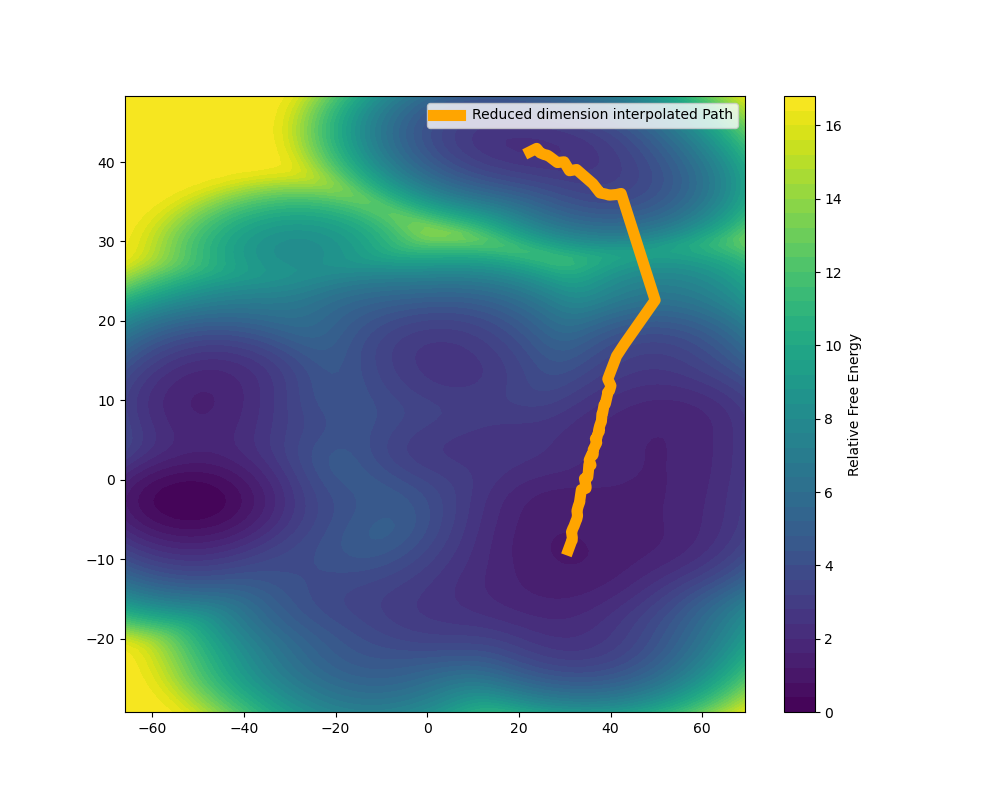

In [18]:
# First Path
selected_minima = np.array([
    [23.0,41.80],
    [46.9, 28.56],
    [31.0, -8.59],
    # [6.8, -13.83], 
    # [-25.0, -12.06], 
    # [-50.9, -2.49], 
    # [-48.6, 9.76],
    # [-27.9, 28.99],
    # [4.8, 14.43], 
])



# Interpolate between selected minima
x_interp = []
y_interp = []
indices = []  # Store the indices of the closest points

for i in range(len(selected_minima) - 1):
    x_min = selected_minima[i:i+2, 0]
    y_min = selected_minima[i:i+2, 1]
    t = np.linspace(0, 1, 100)  # Interpolation range

    for t_val in t:
        target_point = np.array([
            np.interp(t_val, [0, 1], [x_min[0], x_min[1]]),
            np.interp(t_val, [0, 1], [y_min[0], y_min[1]])
        ])
        closest_index, closest_point = find_closest_point_with_index(target_point, np.vstack([pc1, pc2]).T)
        x_interp.append(closest_point[0])
        y_interp.append(closest_point[1])
        indices.append(closest_index)  # Append the index of the closest point

# Convert lists to arrays
x_interp = np.array(x_interp)
y_interp = np.array(y_interp)
indices = np.array(indices)

# Visualize the results
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, F, levels=50, cmap="viridis")  # Contour plot of free energy
# plt.plot(selected_minima[:, 0], selected_minima[:, 1], 'ro', label="Selected Minima", markersize=10)
plt.plot(x_interp, y_interp, label="Reduced dimension interpolated Path", color='orange', linewidth=8)
# plt.scatter(pc1, pc2, alpha=0.3, label="Projected Data", color='blue')

plt.legend()
# plt.title("Free Energy Landscape with Interpolated Path Through Actual Points")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
plt.colorbar(label="Relative Free Energy")
plt.show()

In [9]:
# import numpy as np

# # Example set of XYZ points
# points = all_z[indices]

# # Number of interpolation points between each pair
# num_interp_points = 20

# # Function to compute the Euclidean distance between two points
# def distance(p1, p2):
#     return np.linalg.norm(p1 - p2)

# # Interpolate between the closest points using SLERP
# interp_points = []

# # To keep track of already processed points
# processed = set()

# # Start with any arbitrary point and process each point
# for i in range(len(points)):
#     if i in processed:
#         continue
    
#     p1 = points[i]
    
#     # Find the closest point to p1 that hasn't been processed
#     min_dist = float('inf')
#     closest_idx = -1
    
#     for j in range(len(points)):
#         if i != j and j not in processed:
#             p2 = points[j]
#             dist = distance(p1, p2)
#             if dist < min_dist:
#                 min_dist = dist
#                 closest_idx = j
    
#     p2 = points[closest_idx]
    
#     # Mark both points as processed
#     processed.add(i)
#     processed.add(closest_idx)
    
#     # SLERP interpolation: t goes from 0 to 1
#     for t in np.linspace(0, 1, num_interp_points):
#         interp_points.append(slerp(p1, p2, t))

# # Convert the interpolated points to a numpy array
# interp_points = np.array(interp_points)


In [11]:
"""
Here we get the index from previous path and perform curve fitting in latent space
"""

points = all_z[indices]

# Create a parameter t based on the index of points
t = np.linspace(0, 1, len(points))

# Fit cubic functions for x, y, and z
params_x, _ = curve_fit(cubic, t, points[:, 0])
params_y, _ = curve_fit(cubic, t, points[:, 1])
params_z, _ = curve_fit(cubic, t, points[:, 2])


num_points = 10000   # number of points of fitted curve

# Generate the fitted curve
t_fit = np.linspace(0, 1, num_points)
x_fit = cubic(t_fit, *params_x)
y_fit = cubic(t_fit, *params_y)
z_fit = cubic(t_fit, *params_z)

# Combine fitted curve points
fitted_curve = np.vstack((x_fit, y_fit, z_fit)).T

In [12]:
from scipy.spatial.distance import cdist

def find_closest_point(point, curve_points):
    """Find the index of the closest point on the curve."""
    distances = cdist([point], curve_points)
    return np.argmin(distances)

# Define initial and final points
initial_point = all_z[indices][0]  # replace with actual values
final_point = all_z[indices][-1] # replace with actual values


# Find the closest points on the fitted curve
closest_start_idx = find_closest_point(initial_point, fitted_curve)
closest_end_idx = find_closest_point(final_point, fitted_curve)

# Ensure start comes before the end
if closest_start_idx > closest_end_idx:
    closest_start_idx, closest_end_idx = closest_end_idx, closest_start_idx

# Extract the curve section between the closest points
curve_section = fitted_curve[closest_start_idx:closest_end_idx + 1]

# Interpolate the curve section to have exactly 10,000 points
num_interpolated_points = 10000
t_section = np.linspace(0, 1, len(curve_section))  # Create parameter t for the section
t_interpolated = np.linspace(0, 1, num_interpolated_points)  # New parameter t for 10,000 points

# Interpolate each dimension (x, y, z) separately
interp_x = interp1d(t_section, curve_section[:, 0], kind='cubic')
interp_y = interp1d(t_section, curve_section[:, 1], kind='cubic')
interp_z = interp1d(t_section, curve_section[:, 2], kind='cubic')

# Generate the interpolated curve section
x_interpolated = interp_x(t_interpolated)
y_interpolated = interp_y(t_interpolated)
z_interpolated = interp_z(t_interpolated)

# Combine the interpolated curve points
interpolated_curve_section = np.vstack((x_interpolated, y_interpolated, z_interpolated)).T

# Combine initial point, interpolated curve section, and final point
new_curve = np.vstack((initial_point, interpolated_curve_section, final_point))

print("Generated new curve points:", new_curve)



Generated new curve points: [[ 22.67983818 -16.5734272   52.40117264]
 [ 21.21863366 -16.51527702  52.02568264]
 [ 21.21659093 -16.51613615  52.03350466]
 ...
 [-13.21953837 -45.52971748  37.65017023]
 [-13.22407168 -45.52908452  37.64171847]
 [-12.59021187 -50.15116119  36.96080017]]


In [13]:
"""
Here from the fitted curve, we explore the slerp path way
"""

def interpolate_centers_slerp(centers, center_order, n_points=1000):
    interpolated = []
    for i in range(len(center_order)-1):
        start = centers[center_order[i]]
        end = centers[center_order[(i + 1)]]
        for t in np.linspace(0, 1, n_points):
            interpolated.append(slerp(start, end, t))
    return np.array(interpolated)

def interpolate_centers_slerp_point(center1, center2, n_points=10000):
    interpolated = []
    start = center1
    end = center2
    for t in np.linspace(0, 1, n_points):
        interpolated.append(slerp(start, end, t))
    return np.array(interpolated)

def spherical_expansion(data_point, num_points=5, radius=1.0):

    # Normalize the original data point
    norm_data_point = data_point / np.linalg.norm(data_point)

    expanded_points = []
    
    # Generate num_points random points along the sphere
    for _ in range(num_points):
        # Generate a random unit vector by normalizing a random vector from normal distribution
        random_unit_vector = np.random.randn(len(data_point))
        random_unit_vector /= np.linalg.norm(random_unit_vector)  # Normalize it
        
        # Perturb the original data point by the random direction scaled by the radius
        new_point = data_point + radius * random_unit_vector
        expanded_points.append(new_point)
    
    return np.array(expanded_points)



center1 = interpolated_curve_section[0]
center2 = interpolated_curve_section[-1]
interpolated_points = interpolate_centers_slerp_point(center1, center2)
interpolated_points

array([[ 21.21863366, -16.51527702,  52.02568264],
       [ 21.21552304, -16.51910948,  52.02590503],
       [ 21.21241229, -16.52294183,  52.02612707],
       ...,
       [-13.21728678, -45.52579313,  37.64759457],
       [-13.22067927, -45.52743898,  37.64465664],
       [-13.22407168, -45.52908452,  37.64171847]])

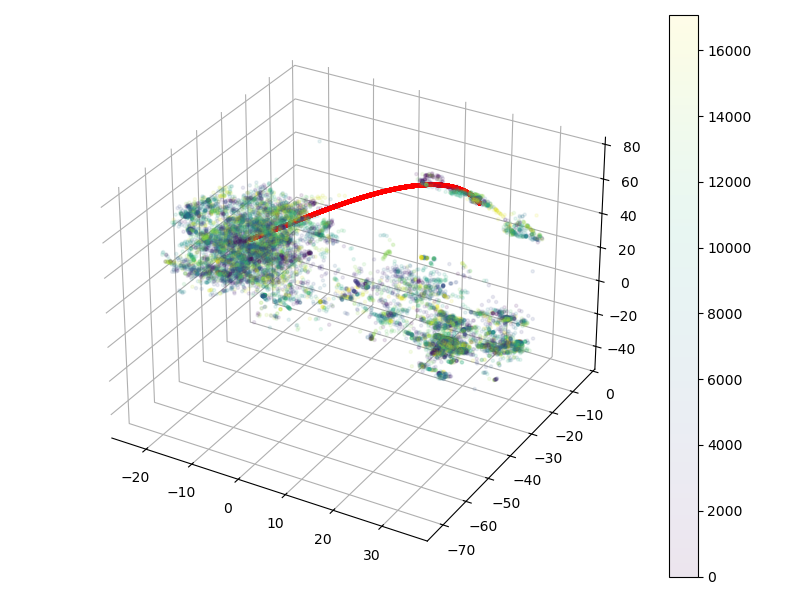

In [14]:
"""
Here we visualize the curve fitting path and the interpolated path in latent space
"""

cmapT='viridis'
cmapV='winter'

fig = plt.figure(figsize = [8, 6])
ax = plt.axes(projection='3d')
p1 = ax.scatter3D(all_z[:,0], all_z[:,1], all_z[:,2], c=range(int(len(all_z))), alpha=0.1, cmap=cmapT, s=5)
# p2 = ax.scatter3D(all_z[indices][:,0], all_z[indices][:,1],all_z[indices][:,2], alpha=0.99, s=10,color='orange')
# p3 = ax.scatter3D(interpolated_points[:,0], interpolated_points[:,1], interpolated_points[:,2], alpha=0.99,s=5, color='blue')
# p4 = ax.scatter3D(interp_points[:,0], interp_points[:,1], interp_points[:,2], alpha=0.99,s=5, color='black')
p5 = ax.scatter3D(interpolated_curve_section[:,0], interpolated_curve_section[:,1], interpolated_curve_section[:,2], ls='-',alpha=0.99,s=5, color='red')
# ax.plot3D(interpolated_curve_section[:,0], interpolated_curve_section[:,1], interpolated_curve_section[:,2], 'black', ls='-', marker='o', markersize=4)
# p3 = ax.scatter3D(centers[:,0], centers[:,1], centers[:,2], alpha=0.99, color='red')
# p3 = ax.scatter3D(expanded_points[:,0], expanded_points[:,1], expanded_points[:,2], alpha=0.99, color='red',s=1)



fig.colorbar(p1, ax=ax)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

# ax.set_xlabel('Z1'); ax.set_ylabel('Z2'); ax.set_zlabel('Z3')
fig.tight_layout()
#plt.savefig('3D_latent_9000-9100.png')
plt.show()

In [22]:
"""
Save the coordinate of interpolated path in latent space. Then use the decoder to generate the conformation
"""

# np.save(out_path + 'visual/interpolated_latent_points_slerp.npy', all_z[indices])       # save the red dot of original MD frame
# np.save(out_path + 'visual/interpolated_latent_points_slerp.npy', interpolated_points)         # save the blue curve (slerp)
np.save(out_path + 'visual/interpolated_latent_points_slerp.npy', interpolated_curve_section)           # save the red curve  (fitcurve)